In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import init_printing
import sympy as sym
from scipy.integrate import solve_ivp
#init_printing()

In [26]:
A = np.array([[0,1,1,0,1,0,0],[0,0,1,0,0,0,0],[0,0,0,1,0,0,0],[0,0,0,0,1,0,0],[0,0,0,0,0,1,0],[0,0,0,0,0,0,1],[1,0,0,0,0,0,0]]).T
sym.Matrix(A)

Matrix([
[0, 0, 0, 0, 0, 0, 1],
[1, 0, 0, 0, 0, 0, 0],
[1, 1, 0, 0, 0, 0, 0],
[0, 0, 1, 0, 0, 0, 0],
[1, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 1, 0, 0],
[0, 0, 0, 0, 0, 1, 0]])

In [27]:
def get_D_L(A):
    # there's no real reason to code for this part of the problem but maybe this will be handy to have on hand in the future
    # and I don't want to make all these matricies in LaTeX
    n = A.shape[1]
    D = np.diag([sum(A[i,:]) for i in range(n)]) # i LOVE list comprehensions, even though would probably be faster to do something like np.diag(A@np.ones(n))
    L = D-A
    return D,L

D,L = get_D_L(A)

In [28]:
def eval_calculator(A):
    n = A.shape[1]
    evals = np.linalg.eigvals(A)
    evals[abs(evals)<0.0000001]=0.0 # make things close to zero appear as zero
    return evals

print("Eigenvalues of L :")
sym.Matrix(eval_calculator(L))

Eigenvalues of L :


Matrix([
[                                      0],
[0.767214384061616 + 0.792551992515449*I],
[0.767214384061616 - 0.792551992515449*I],
[                       2.46557123187677],
[              1.5 + 0.866025403784439*I],
[              1.5 - 0.866025403784439*I],
[                                    2.0]])

In [29]:
A_eig = eval_calculator(A)
sym.Matrix(A_eig)


Matrix([
[                       1.22074408460576],
[              0.5 + 0.866025403784438*I],
[              0.5 - 0.866025403784438*I],
[-0.248126062802622 + 1.03398206097597*I],
[-0.248126062802622 - 1.03398206097597*I],
[                                   -1.0],
[                     -0.724491959000516]])

In [30]:
lambda_max = np.real(A_eig).max()
d = 1
d_homo = np.identity(7)*d
u_star_homo = d/(lambda_max+1)

In [31]:
M = u_star_homo*A + (-d +u_star_homo)*np.identity(7)

In [32]:
sym.Matrix(eval_calculator(M))

Matrix([
[                                       0],
[-0.324550716852955 + 0.389970825448886*I],
[-0.324550716852955 - 0.389970825448886*I],
[-0.661431525402057 + 0.465601627915415*I],
[-0.661431525402057 - 0.465601627915415*I],
[                                    -1.0],
[                      -0.875938860803768]])

In [33]:
sym.Matrix(A_eig*u_star_homo + (u_star_homo -d))

Matrix([
[                                       0],
[-0.324550716852955 + 0.389970825448886*I],
[-0.324550716852955 - 0.389970825448886*I],
[-0.661431525402056 + 0.465601627915414*I],
[-0.661431525402056 - 0.465601627915414*I],
[                                    -1.0],
[                      -0.875938860803768]])

2.2 (a)

homogeneous linear weight case:

In [38]:
B = np.diag([A[i,i] for i in range(7)])
sym.Matrix(B)

Matrix([
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0]])

In [173]:
d=1
B = np.identity(7)
u_star_homo = d/(lambda_max+1)
M_homo = u_star_homo*A - d*np.identity(7)+u_star_homo*B

def find_w(L):
    vals, vecs = np.linalg.eig(L.T)
    w = vecs.T[np.argmin(np.abs(vals))] # select eigvec with associated zero eigenvalue
    return w/(w.T@np.ones(7)) # normalize

def find_v(L):
    vals, vecs = np.linalg.eig(L)
    w = vecs.T[np.argmin(np.abs(vals))] # select eigvec with associated zero eigenvalue
    return w/(w.T@np.ones(7)) # normalize

wa = find_w(M_homo)
va =find_v(M_homo)
print("w",wa)
print("v",va)

w [0.24031184+0.j 0.07261518+0.j 0.08864455+0.j 0.10821231+0.j
 0.13209954+0.j 0.16125973+0.j 0.19685686+0.j]
v [0.11037204+0.j 0.09041374+0.j 0.1644782 +0.j 0.13473602+0.j
 0.20078579+0.j 0.1644782 +0.j 0.13473602+0.j]


In [174]:
eval_calculator(M_homo)

array([ 0.        +0.j        , -0.32455072+0.38997083j,
       -0.32455072-0.38997083j, -0.66143153+0.46560163j,
       -0.66143153-0.46560163j, -1.        +0.j        ,
       -0.87593886+0.j        ])

In [175]:
D,L = get_D_L(A)
wb = find_w(-L)
vb = find_v(-L)

sym.latex(sym.Matrix(vb))

'\\left[\\begin{matrix}0.142857142857143\\\\0.142857142857143\\\\0.142857142857143\\\\0.142857142857143\\\\0.142857142857143\\\\0.142857142857143\\\\0.142857142857143\\end{matrix}\\right]'

In [164]:
find_w(A)

array([ 0.22573084-0.j,  1.56095178-0.j, -1.13089701-0.j,  0.81932579-0.j,
       -0.59359495-0.j,  0.43005477-0.j, -0.31157122-0.j])

2.2 c

In [88]:
u_star_homo

0.45029952209803015

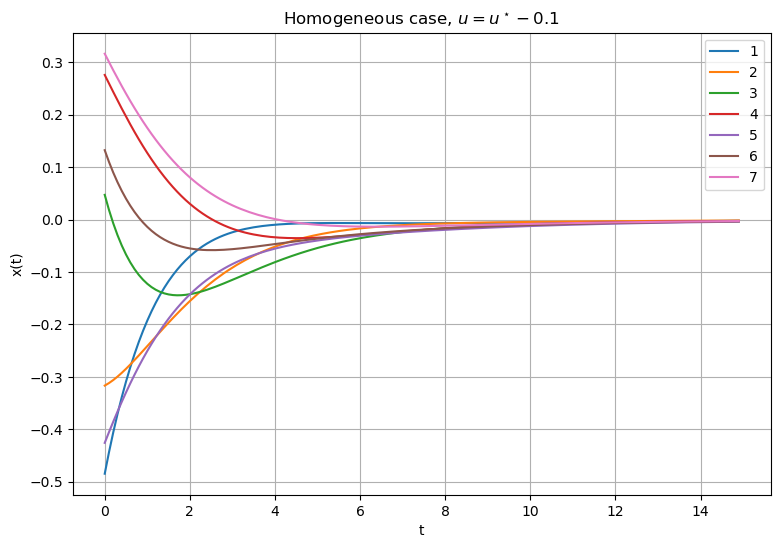

In [98]:
u = u_star_homo - 0.1
def f_homo(t,x):
    xdot = np.zeros(7,float)
    for i in range(7):
        xdot[i] = -d*x[i] + np.tanh(u*(x[i] + sum([A[i,j]*x[j] for j in range(7)]))) 
    return xdot

tspan = (0,15)
x0 = np.random.uniform(-0.5,0.5,7)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f_homo,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i],label = str(i+1))
plt.grid()
plt.ylabel("x(t)")
plt.title(r"Homogeneous case, $u = u^\star - 0.1$")
plt.xlabel("t")
plt.legend()
plt.show()

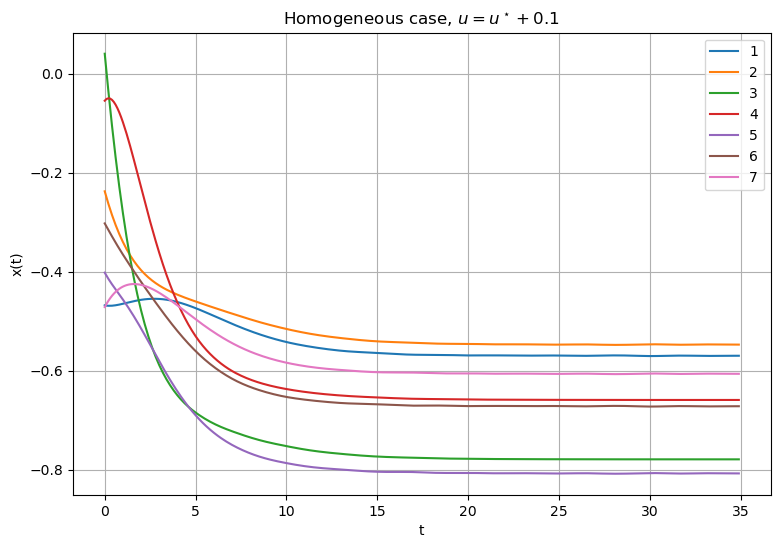

In [120]:
u = u_star_homo + 0.1
def f_homo(t,x):
    xdot = np.zeros(7,float)
    for i in range(7):
        xdot[i] = -d*x[i] + np.tanh(u*(x[i] + sum([A[i,j]*x[j] for j in range(7)]))) 
    return xdot

tspan = (0,35)
x0 = np.random.uniform(-0.5,0.5,7)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f_homo,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i],label = str(i+1))
plt.grid()
plt.ylabel("x(t)")
plt.title(r"Homogeneous case, $u = u^\star + 0.1$")
plt.xlabel("t")
plt.legend()

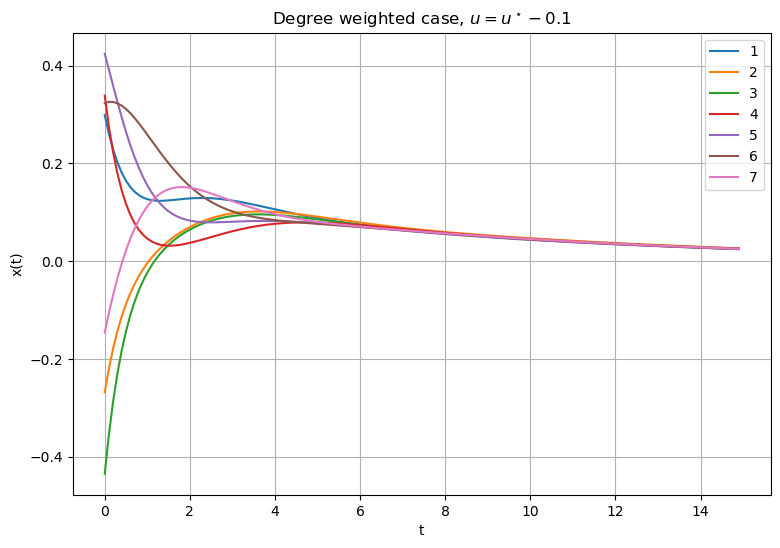

In [103]:
u = 1-0.1
def f_hetero(t,x):
    xdot = np.zeros(7,float)
    for i in range(7):
        xdot[i] = -D[i,i]*x[i] + np.tanh(u*(A[i,i]*x[i] + sum([A[i,j]*x[j] for j in range(7)]))) 
    return xdot

tspan = (0,15)
x0 = np.random.uniform(-0.5,0.5,7)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f_hetero,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i],label = str(i+1))
plt.grid()
plt.ylabel("x(t)")
plt.title(r"Degree weighted case, $u = u^\star - 0.1$")
plt.xlabel("t")
plt.legend()
plt.show()

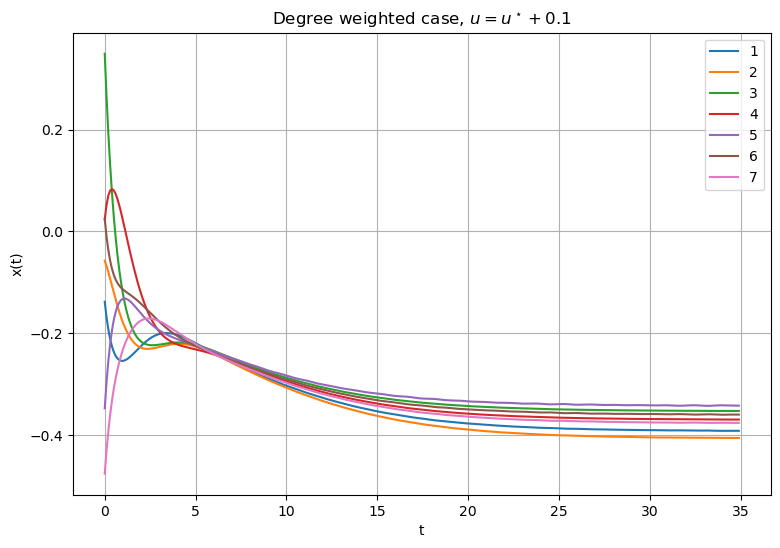

In [154]:
u = 1+0.1
def f_hetero(t,x):
    xdot = np.zeros(7,float)
    for i in range(7):
        xdot[i] = -D[i,i]*x[i] + np.tanh(u*(A[i,i]*x[i] + sum([A[i,j]*x[j] for j in range(7)]))) 
    return xdot

tspan = (0,35)
x0 = np.random.uniform(-0.5,0.5,7)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f_hetero,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i],label = str(i+1))
plt.grid()
plt.ylabel("x(t)")
plt.title(r"Degree weighted case, $u = u^\star + 0.1$")
plt.xlabel("t")
plt.legend()
plt.show()

part (e)

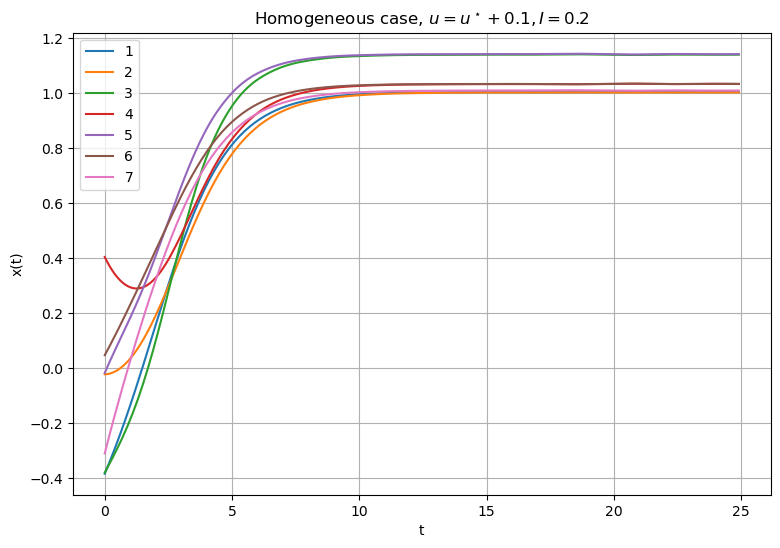

In [135]:
u = u_star_homo + 0.1
def f_homo(t,x):
    xdot = np.zeros(7,float)
    for i in range(7):
        xdot[i] = -d*x[i] + np.tanh(u*(x[i] + sum([A[i,j]*x[j] for j in range(7)])))+I[i] 
    return xdot

tspan = (0,25)
x0 = np.random.uniform(-0.5,0.5,7)
I = 0.2*np.ones(7)
t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f_homo,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i],label = str(i+1))
plt.grid()
plt.ylabel("x(t)")
plt.title(r"Homogeneous case, $u = u^\star + 0.1, I = 0.2$")
plt.xlabel("t")
plt.legend()
plt.show()

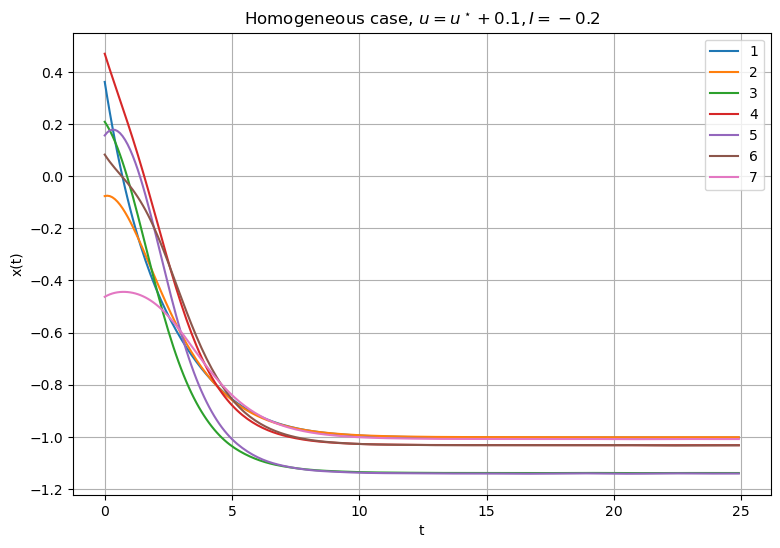

In [136]:
u = u_star_homo + 0.1
def f_homo(t,x):
    xdot = np.zeros(7,float)
    for i in range(7):
        xdot[i] = -d*x[i] + np.tanh(u*(x[i] + sum([A[i,j]*x[j] for j in range(7)])))+I[i] 
    return xdot

tspan = (0,25)
x0 = np.random.uniform(-0.5,0.5,7)
I = -0.2*np.ones(7)
t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f_homo,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i],label = str(i+1))
plt.grid()
plt.ylabel("x(t)")
plt.title(r"Homogeneous case, $u = u^\star + 0.1, I = -0.2$")
plt.xlabel("t")
plt.legend()
plt.show()

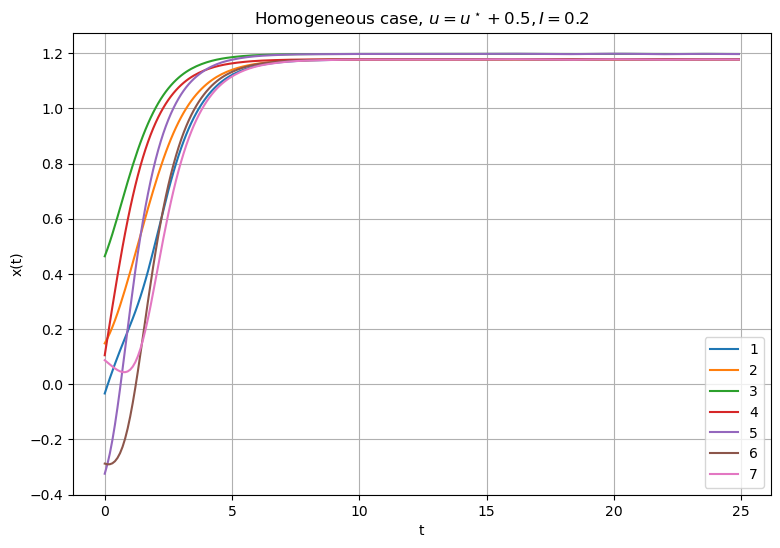

In [138]:
u = u_star_homo + 0.5
def f_homo(t,x):
    xdot = np.zeros(7,float)
    for i in range(7):
        xdot[i] = -d*x[i] + np.tanh(u*(x[i] + sum([A[i,j]*x[j] for j in range(7)])))+I[i] 
    return xdot

tspan = (0,25)
x0 = np.random.uniform(-0.5,0.5,7)
I = 0.2*np.ones(7)
t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f_homo,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i],label = str(i+1))
plt.grid()
plt.ylabel("x(t)")
plt.title(r"Homogeneous case, $u = u^\star + 0.5, I = 0.2$")
plt.xlabel("t")
plt.legend()
plt.show()

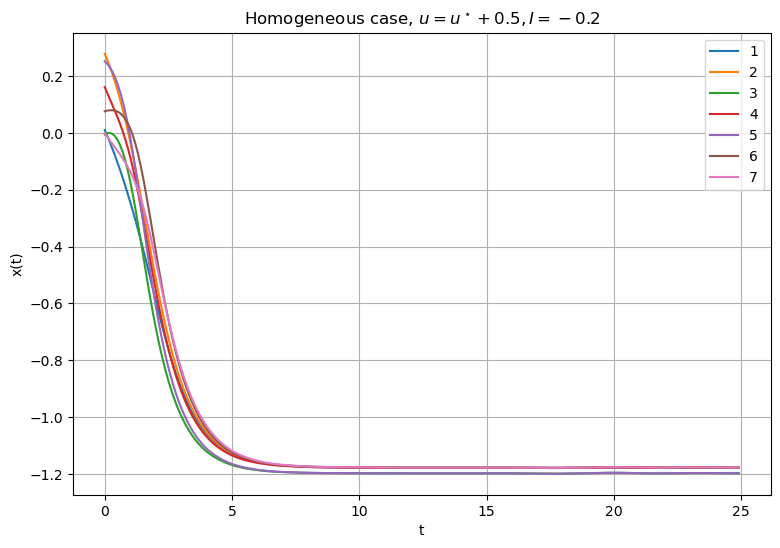

In [150]:
u = u_star_homo + 0.5
def f_homo(t,x):
    xdot = np.zeros(7,float)
    for i in range(7):
        xdot[i] = -d*x[i] + np.tanh(u*(x[i] + sum([A[i,j]*x[j] for j in range(7)])))+I[i] 
    return xdot

tspan = (0,25)
x0 = np.random.uniform(-0.5,0.5,7)
#x0 = 1*np.ones(7)
I = -0.2*np.ones(7)
t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f_homo,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i],label = str(i+1))
plt.grid()
plt.ylabel("x(t)")
plt.title(r"Homogeneous case, $u = u^\star + 0.5, I = -0.2$")
plt.xlabel("t")
plt.legend()
plt.show()

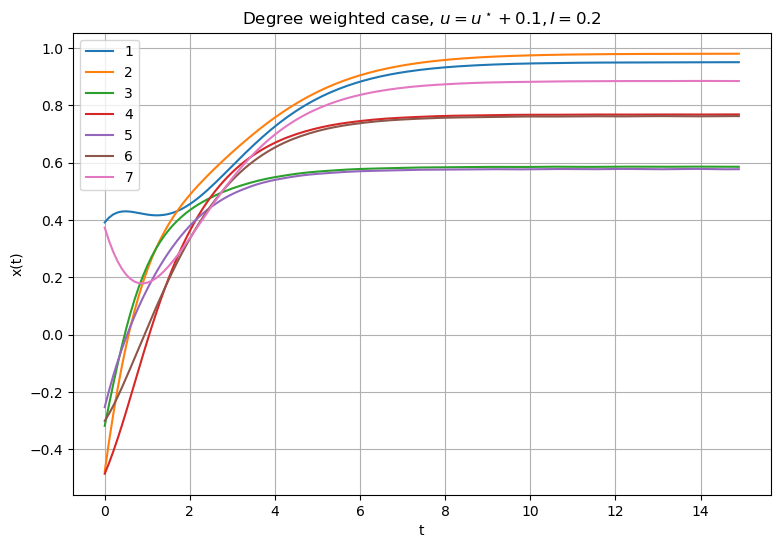

In [157]:
u = 1+0.1
def f_hetero(t,x):
    xdot = np.zeros(7,float)
    for i in range(7):
        xdot[i] = -D[i,i]*x[i] + np.tanh(u*(A[i,i]*x[i] + sum([A[i,j]*x[j] for j in range(7)]))) +0.2
    return xdot

tspan = (0,15)
x0 = np.random.uniform(-0.5,0.5,7)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f_hetero,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i],label = str(i+1))
plt.grid()
plt.ylabel("x(t)")
plt.title(r"Degree weighted case, $u = u^\star + 0.1, I = 0.2$")
plt.xlabel("t")
plt.legend()
plt.show()

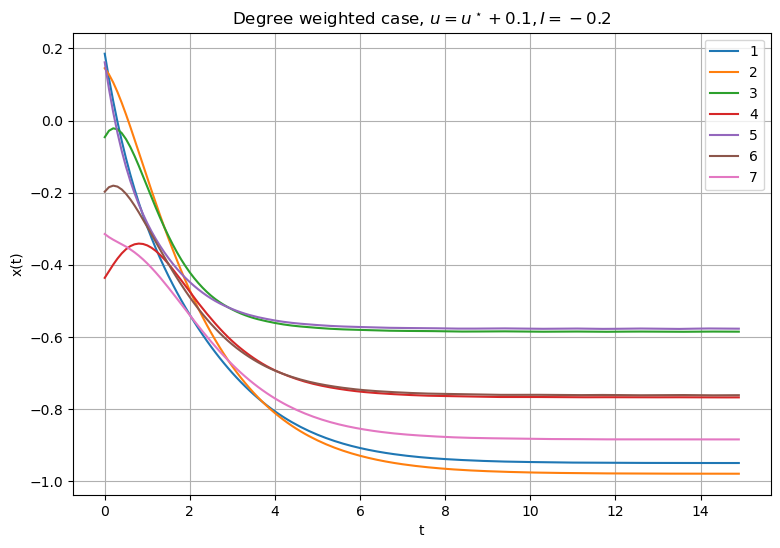

In [159]:
u = 1+0.1
def f_hetero(t,x):
    xdot = np.zeros(7,float)
    for i in range(7):
        xdot[i] = -D[i,i]*x[i] + np.tanh(u*(A[i,i]*x[i] + sum([A[i,j]*x[j] for j in range(7)]))) -0.2
    return xdot

tspan = (0,15)
x0 = np.random.uniform(-0.5,0.5,7)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f_hetero,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i],label = str(i+1))
plt.grid()
plt.ylabel("x(t)")
plt.title(r"Degree weighted case, $u = u^\star + 0.1, I = -0.2$")
plt.xlabel("t")
plt.legend()
plt.show()

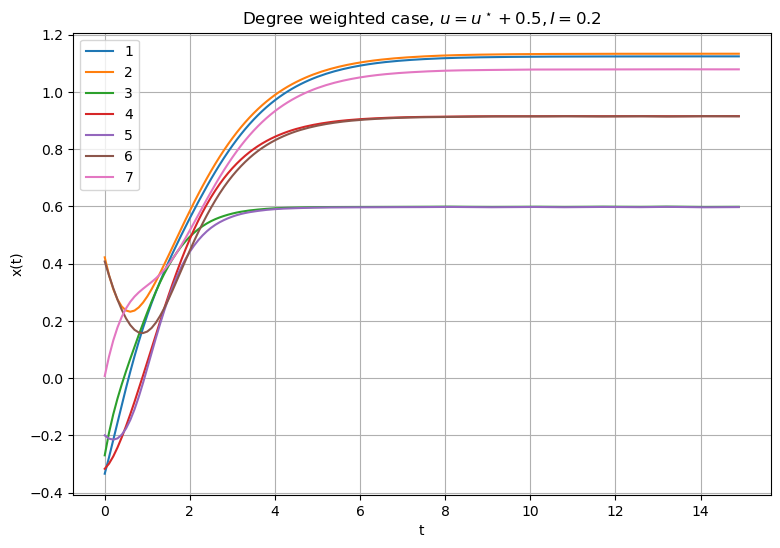

In [160]:
u = 1+0.5
def f_hetero(t,x):
    xdot = np.zeros(7,float)
    for i in range(7):
        xdot[i] = -D[i,i]*x[i] + np.tanh(u*(A[i,i]*x[i] + sum([A[i,j]*x[j] for j in range(7)]))) +0.2
    return xdot

tspan = (0,15)
x0 = np.random.uniform(-0.5,0.5,7)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f_hetero,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i],label = str(i+1))
plt.grid()
plt.ylabel("x(t)")
plt.title(r"Degree weighted case, $u = u^\star + 0.5, I = 0.2$")
plt.xlabel("t")
plt.legend()
plt.show()

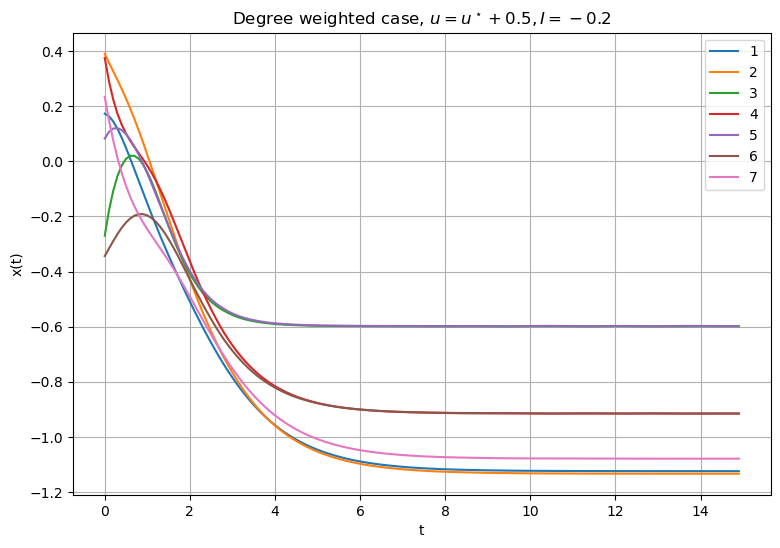

In [161]:
u = 1+0.5
def f_hetero(t,x):
    xdot = np.zeros(7,float)
    for i in range(7):
        xdot[i] = -D[i,i]*x[i] + np.tanh(u*(A[i,i]*x[i] + sum([A[i,j]*x[j] for j in range(7)]))) -0.2
    return xdot

tspan = (0,15)
x0 = np.random.uniform(-0.5,0.5,7)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f_hetero,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i],label = str(i+1))
plt.grid()
plt.ylabel("x(t)")
plt.title(r"Degree weighted case, $u = u^\star + 0.5, I = -0.2$")
plt.xlabel("t")
plt.legend()
plt.show()